# 06 - E6 zq alignment

Comparacion E6 entre VQSA paper-faithful, alineacion suave sobre `zq`, EMA VQ con k-means/reinicio, SimVQ lineal y FSQ.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dememte').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT)

repo root: /home/nakato/projects/Dememte


In [2]:
import json
from dataclasses import asdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dememte.config import E6Config, E6_SPECS, e6_config
from dememte.data import build_loaders, seed_everything
from dememte.models import make_dememte_e6
from dememte.training import train_dememte_vqsa
from dememte.evaluation import evaluate_dememte_suite, signal_curve_rows
from dememte.io import load_checkpoint, save_checkpoint, write_json, write_csv, ensure_dir

RUN_TRAINING = True
FORCE_RETRAIN = False
VARIANTS = ['e6_paper_faithful', 'e6_zq_align_mse', 'e6_ema_kmeans_restart', 'e6_simvq_linear', 'e6_fsq']

base_cfg = E6Config()
for candidate in [ROOT / 'experiments' / 'data', ROOT / 'data', Path(base_cfg.data_dir).expanduser()]:
    candidate = candidate.resolve()
    if (candidate / 'flowers-102').exists() or candidate.name == 'flowers-102':
        base_cfg.data_dir = str(candidate)
        break
device = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT = ensure_dir(ROOT / 'notebooks' / '06_e6_zq_alignment' / 'out')
seed_everything(base_cfg.seed)

print('device:', device)
print(json.dumps(asdict(base_cfg), indent=2))

device: cuda
{
  "data_dir": "/home/nakato/projects/Dememte/experiments/data",
  "num_classes": 102,
  "batch_size": 16,
  "num_workers": 2,
  "device": "cuda",
  "val_ratio": 0.2,
  "split_seed": 42,
  "benchmark_protocol": "historical_trainval_resplit",
  "lr_vq": 0.0003,
  "lr_cls": 0.0001,
  "weight_decay": 0.0001,
  "epochs_vqsa_max": 10,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 2,
  "latent_dim": 256,
  "num_embeddings": 1024,
  "commitment_cost": 0.25,
  "vq_temperature": 1.0,
  "vq_weight": 1.0,
  "quantizer_type": "vq",
  "vq_ema_decay": 0.99,
  "vq_kmeans_init": false,
  "vq_kmeans_steps": 10,
  "dead_code_restart": false,
  "dead_code_restart_after_epoch": 1,
  "dead_code_threshold": 1.0,
  "dead_code_restart_jitter": 0.01,
  "fsq_levels": 8,
  "vqsa_heads": 4,
  "vqsa_layers": 2,
  "vqsa_dropout": 0.1,
  "vqsa_fusion_mode": "concat",
  "vqsa_use_codebook": true,
  "vqsa_use_self_attention": true,
  "vqs

## Datos compartidos

In [3]:
tr_loader, va_loader, te_loader, meta = build_loaders(
    data_dir=base_cfg.data_dir,
    batch_size=base_cfg.batch_size,
    num_workers=base_cfg.num_workers,
    val_ratio=base_cfg.val_ratio,
    split_seed=base_cfg.split_seed,
    protocol=base_cfg.benchmark_protocol,
)
print(meta)

{'protocol': 'historical_trainval_resplit', 'split_seed': 42, 'train_size': 1632, 'val_size': 408, 'test_size': 6149}


## Variantes E6

In [4]:
for name in VARIANTS:
    print(f'{name:24s} :: {E6_SPECS[name]["label"]}')

e6_paper_faithful        :: E6 paper-faithful VQSA
e6_zq_align_mse          :: E6 zq MSE alignment
e6_ema_kmeans_restart    :: E6 EMA VQ + k-means init + dead-code restart
e6_simvq_linear          :: E6 SimVQ linear codebook
e6_fsq                   :: E6 finite scalar quantization


## Entrenamiento, evaluacion y persistencia

In [5]:
def checkpoint_for_variant(variant):
    return OUT / variant / 'best.pt'


all_summaries = []
all_curves = []

for variant in VARIANTS:
    print(f'=== {variant} ===')
    vdir = ensure_dir(OUT / variant)
    cfg = e6_config(variant)
    cfg.data_dir = base_cfg.data_dir
    seed_everything(cfg.seed)
    model = make_dememte_e6(cfg, device=device)
    ckpt_path = checkpoint_for_variant(variant)

    if RUN_TRAINING and (FORCE_RETRAIN or not ckpt_path.exists()):
        model, best_acc = train_dememte_vqsa(model, tr_loader, va_loader, cfg, device)
        save_checkpoint(model, ckpt_path, extra={'best_val': best_acc, 'config': asdict(cfg)})
        print('saved checkpoint:', ckpt_path, '| best_val:', best_acc)
    else:
        if not ckpt_path.exists():
            raise FileNotFoundError(f'Missing E6 checkpoint for {variant}: {ckpt_path}. Set RUN_TRAINING=True.')
        payload = load_checkpoint(model, ckpt_path, device=device, strict=True)
        print('loaded checkpoint:', ckpt_path, '| best_val:', payload.get('best_val'))

    metrics = evaluate_dememte_suite(model, te_loader, device=device)
    clean_record = metrics.pop('clean_record')
    corrupt_records = metrics.pop('corruption_records')
    curve_rows = signal_curve_rows(variant, E6_SPECS[variant]['label'], clean_record, corrupt_records)

    summary = {k: v for k, v in metrics.items() if isinstance(v, (int, float, bool))}
    summary.update({
        'variant': variant,
        'label': E6_SPECS[variant]['label'],
        'checkpoint': str(ckpt_path),
        'protocol': meta['protocol'],
        'split_seed': meta['split_seed'],
        'quantizer_type': cfg.quantizer_type,
        'vqsa_align_mode': cfg.vqsa_align_mode,
        'align_weight': cfg.align_weight,
    })
    summary['assignment_entropy_gap_clean_minus_corrupt'] = summary.get('assignment_entropy_clean', 0.0) - summary.get('assignment_entropy_corrupt_avg', 0.0)
    summary['codebook_perplexity_gap_clean_minus_corrupt'] = summary.get('codebook_perplexity_clean', 0.0) - summary.get('codebook_perplexity_corrupt_avg', 0.0)

    write_json(summary, vdir / 'metrics.json')
    write_csv(curve_rows, vdir / 'signal_curves.csv')
    all_summaries.append(summary)
    all_curves.extend(curve_rows)

summary_df = pd.DataFrame(all_summaries)
write_csv(all_summaries, OUT / 'e6_results.csv')
write_csv(all_curves, OUT / 'e6_curves.csv')
summary_df

=== e6_paper_faithful ===
loaded checkpoint: /home/nakato/projects/Dememte/notebooks/06_e6_zq_alignment/out/e6_paper_faithful/best.pt | best_val: 0.7524509803921569
=== e6_zq_align_mse ===
loaded checkpoint: /home/nakato/projects/Dememte/notebooks/06_e6_zq_alignment/out/e6_zq_align_mse/best.pt | best_val: 0.7524509803921569
=== e6_ema_kmeans_restart ===
[VQSA 01] tr_loss=3.9598 tr_acc=0.1253 val_loss=2.7092 val_acc=0.3824 val_vq=0.0690 tr_align=0.0000 val_usage=0.1318 val_hard_ppl=41.52
[VQSA 02] tr_loss=2.4755 tr_acc=0.3799 val_loss=1.7604 val_acc=0.5760 val_vq=0.0678 tr_align=0.0000 val_usage=0.2451 val_hard_ppl=95.01
[VQSA 03] tr_loss=1.7557 tr_acc=0.5435 val_loss=1.4747 val_acc=0.6299 val_vq=0.0664 tr_align=0.0000 val_usage=0.2881 val_hard_ppl=107.78
[VQSA 04] tr_loss=1.4347 tr_acc=0.6216 val_loss=1.2398 val_acc=0.6887 val_vq=0.0639 tr_align=0.0000 val_usage=0.2920 val_hard_ppl=109.94
[VQSA 05] tr_loss=1.2353 tr_acc=0.6743 val_loss=1.2546 val_acc=0.7059 val_vq=0.0628 tr_align=0.000

,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur,ece_clean,ece_corrupt_avg,nll_clean,nll_corrupt_avg,...,variant,label,checkpoint,protocol,split_seed,quantizer_type,vqsa_align_mode,align_weight,assignment_entropy_gap_clean_minus_corrupt,codebook_perplexity_gap_clean_minus_corrupt
0,0.736055,0.495704,0.357131,0.340543,0.624112,0.661029,0.043293,0.080977,0.975917,1.971522,...,e6_paper_faithful,E6 paper-faithful VQSA,/home/nakato/projects/Dememte/notebooks/06_e6_...,historical_trainval_resplit,42,vq,none,0.0,0.062137,1.303191
1,0.716051,0.473885,0.337074,0.324768,0.598688,0.635008,0.049410,0.087410,1.059129,2.123270,...,e6_zq_align_mse,E6 zq MSE alignment,/home/nakato/projects/Dememte/notebooks/06_e6_...,historical_trainval_resplit,42,vq,zq_mse,0.1,0.035215,0.444591
2,0.752317,0.502954,0.353445,0.348675,0.638911,0.670787,0.058221,0.090268,0.976969,2.022439,...,e6_ema_kmeans_restart,E6 EMA VQ + k-means init + dead-code restart,/home/nakato/projects/Dememte/notebooks/06_e6_...,historical_trainval_resplit,42,ema_vq,none,0.0,0.005827,0.063283
3,0.731664,0.480715,0.333767,0.335719,0.607470,0.645904,0.021087,0.062279,1.006049,2.030929,...,e6_simvq_linear,E6 SimVQ linear codebook,/home/nakato/projects/Dememte/notebooks/06_e6_...,historical_trainval_resplit,42,simvq_linear,none,0.0,0.004635,0.046112
4,0.741259,0.503930,0.363907,0.367377,0.634846,0.649591,0.055138,0.097203,1.016278,2.052200,...,e6_fsq,E6 finite scalar quantization,/home/nakato/projects/Dememte/notebooks/06_e6_...,historical_trainval_resplit,42,fsq,none,0.0,0.000000,0.000000


## Comparativo principal

In [6]:
cols = [
    'variant',
    'clean_acc',
    'corrupt_acc_avg',
    'quantizer_type',
    'assignment_entropy_clean',
    'assignment_entropy_corrupt_avg',
    'assignment_entropy_gap_clean_minus_corrupt',
    'codebook_perplexity_clean',
    'codebook_perplexity_corrupt_avg',
    'codebook_perplexity_gap_clean_minus_corrupt',
    'hard_usage_clean',
    'hard_usage_corrupt_avg',
    'hard_perplexity_clean',
    'hard_perplexity_corrupt_avg',
    'dead_code_fraction_clean',
    'dead_code_fraction_corrupt_avg',
    'align_weight',
]
cols = [c for c in cols if c in summary_df.columns]
ranked = summary_df[cols].sort_values('corrupt_acc_avg', ascending=False)

def write_markdown_table(df, path):
    headers = list(df.columns)
    lines = [
        '| ' + ' | '.join(headers) + ' |',
        '| ' + ' | '.join(['---'] * len(headers)) + ' |',
    ]
    for _, row in df.iterrows():
        lines.append('| ' + ' | '.join(str(row[h]) for h in headers) + ' |')
    path.write_text('\n'.join(lines) + '\n', encoding='utf-8')

write_markdown_table(ranked, OUT / 'e6_summary.md')
ranked

,variant,clean_acc,corrupt_acc_avg,quantizer_type,assignment_entropy_clean,assignment_entropy_corrupt_avg,assignment_entropy_gap_clean_minus_corrupt,codebook_perplexity_clean,codebook_perplexity_corrupt_avg,codebook_perplexity_gap_clean_minus_corrupt,hard_usage_clean,hard_usage_corrupt_avg,hard_perplexity_clean,hard_perplexity_corrupt_avg,dead_code_fraction_clean,dead_code_fraction_corrupt_avg,align_weight
4,e6_fsq,0.741259,0.503930,fsq,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,2.864357,2.859444,0.500000,0.500000,0.0
2,e6_ema_kmeans_restart,0.752317,0.502954,ema_vq,0.089228,0.083401,0.005827,1.882144,1.818862,0.063283,0.738281,0.479248,126.526672,78.933570,0.261719,0.520752,0.0
0,e6_paper_faithful,0.736055,0.495704,vq,0.162135,0.099998,0.062137,3.878576,2.575385,1.303191,0.001953,0.001709,1.008506,1.002764,0.998047,0.998291,0.0
3,e6_simvq_linear,0.731664,0.480715,simvq_linear,0.038480,0.033845,0.004635,1.314241,1.268129,0.046112,0.010742,0.010091,7.319330,6.856951,0.989258,0.989909,0.0
1,e6_zq_align_mse,0.716051,0.473885,vq,0.075596,0.040382,0.035215,1.884504,1.439913,0.444591,0.001953,0.001302,1.000162,1.000098,0.998047,0.998698,0.1


## Visual clean vs corrupt

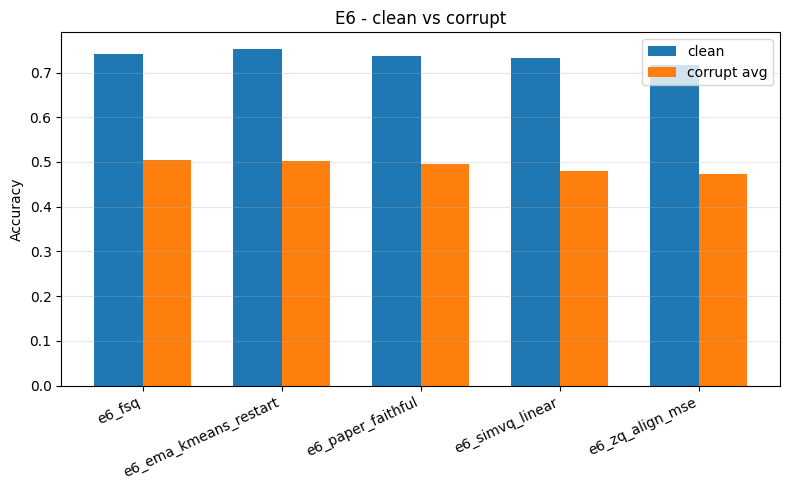

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ranked))
width = 0.35
ax.bar(x - width / 2, ranked['clean_acc'], width, label='clean')
ax.bar(x + width / 2, ranked['corrupt_acc_avg'], width, label='corrupt avg')
ax.set_xticks(x)
ax.set_xticklabels(ranked['variant'], rotation=25, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('E6 - clean vs corrupt')
ax.grid(alpha=0.3, axis='y')
ax.legend()
ensure_dir(OUT / 'plots')
fig.savefig(OUT / 'plots' / 'e6_clean_vs_corrupt.png', dpi=120, bbox_inches='tight')
plt.tight_layout()
plt.show()